## Environment Setup

* Using tvt+z of neighbouring wells
    * Aligning them and matching them
    * Exploiting orientation + direction or propagation

In [27]:
import os
import glob
import numpy as np
np.random.seed(12345)
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import re
import warnings
warnings.filterwarnings('ignore')

In [28]:
IS_KAGGLE = os.path.exists('/kaggle/input')
BASE_DIR = '/kaggle/input/competitions/rogii-wellbore-geology-prediction' if IS_KAGGLE else '../data'

print(f"Running on {'Kaggle' if IS_KAGGLE else 'Local Environment'}")
print(f"Data Directory: {BASE_DIR}")
train_data = os.path.join(BASE_DIR, "train")
file_paths = sorted(os.listdir(train_data))

pattern = re.compile(r'([^/\\]+)__horizontal_well\.csv')

well_names = []
for path in file_paths:
    match = pattern.search(path)
    if match:
        well_names.append(match.group(1))

print("Extracted Well Names:")
print(len(well_names), "Well Names")

Running on Local Environment
Data Directory: ../data
Extracted Well Names:
773 Well Names


(np.float64(2846242.4095),
 np.float64(3048291.3005),
 np.float64(1001816.7725),
 np.float64(1148526.1375))

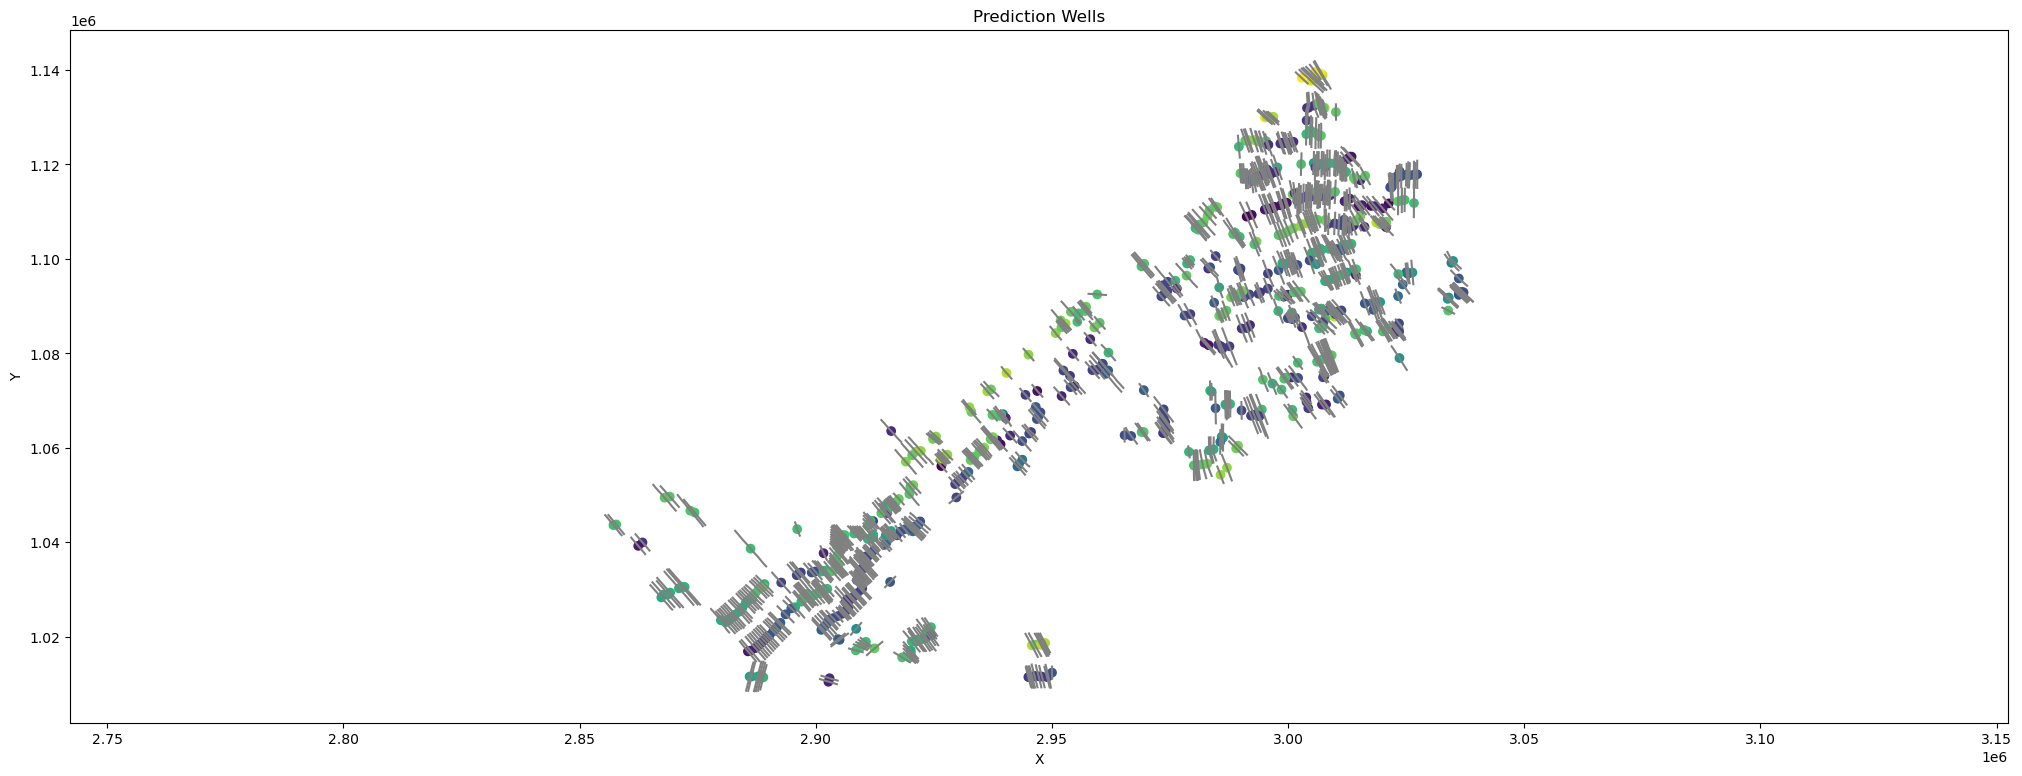

In [29]:
mid_points = list()
ms = list()
plt.figure(figsize=(25, 9))
for well in sorted(well_names[:]):
    hw = pd.read_csv(f'../data/train/{well}__horizontal_well.csv')
    evalz = hw[hw['TVT_input'].isna()]
    plt.plot(evalz['X'], evalz['Y'], color='gray')
    m, c = np.polyfit(evalz['MD'], evalz['Z'], deg=1)
    mid_points.append((evalz['X'].median(), evalz['Y'].median()))
    ms.append(m)
mid_points = np.array(mid_points)
plt.scatter(mid_points[:, 0], mid_points[:, 1], c=ms, marker='o')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Prediction Wells')
plt.axis('equal')

In [30]:
from scipy.spatial import KDTree
start_points = np.array(mid_points)
start_tree = KDTree(mid_points)

In [31]:
import numpy as np
from scipy.spatial.distance import cdist

def calculate_well_similarity(well_a_df, well_b_df):
    """
    Computes physical proximity and parallelism between two wells.
    Expects dataframes with columns: 'X', 'Y', 'TVD' (or 'Z')
    """
    # Extract 3D coordinates
    coords_a = well_a_df[['X', 'Y', 'Z']].values
    coords_b = well_b_df[['X', 'Y', 'Z']].values
    
    # CALCULATE PHYSICAL DISTANCE (Proximity)
    # Get the distance from every point in Well A to the closest point in Well B
    distances_a_to_b = cdist(coords_a, coords_b, metric='euclidean')
    min_distances = np.min(distances_a_to_b, axis=1)
    mean_physical_distance = np.mean(min_distances) # Average distance apart in feet/meters

    vec_a = coords_a[-1] - coords_a[0]
    vec_b = coords_b[-1] - coords_b[0]
    unit_a = vec_a / np.linalg.norm(vec_a)
    unit_b = vec_b / np.linalg.norm(vec_b)
    parallelism = np.dot(unit_a, unit_b)
    
    return {
        "distance_ft": mean_physical_distance,
        "parallelism": parallelism,
    }

## Testing

In [57]:
w1 = np.random.choice(well_names)
# w1 = '1b1eba53'
h1 = pd.read_csv(f'../data/train/{w1}__horizontal_well.csv')
e1 = h1[h1['TVT_input'].isna()]
x1, y1 = e1['X'].median(), e1['Y'].median()
m1, c1 = np.polyfit(e1['MD'], e1['Z'], deg=1)

# Get K closes wells
K = 10 
distances, local_candidate_indices = start_tree.query([x1, y1], k=K)
distances, local_candidate_indices, w1

(array([3574.34592238, 3652.24577284, 3702.91474437, 3724.0714505 ,
        3815.96455886, 3876.04552931, 3941.37728126, 3978.01664871,
        4128.28314444, 4361.61370129]),
 array([ 63, 224, 542, 752, 179, 136, 192, 656, 457, 303]),
 np.str_('4b831d20'))

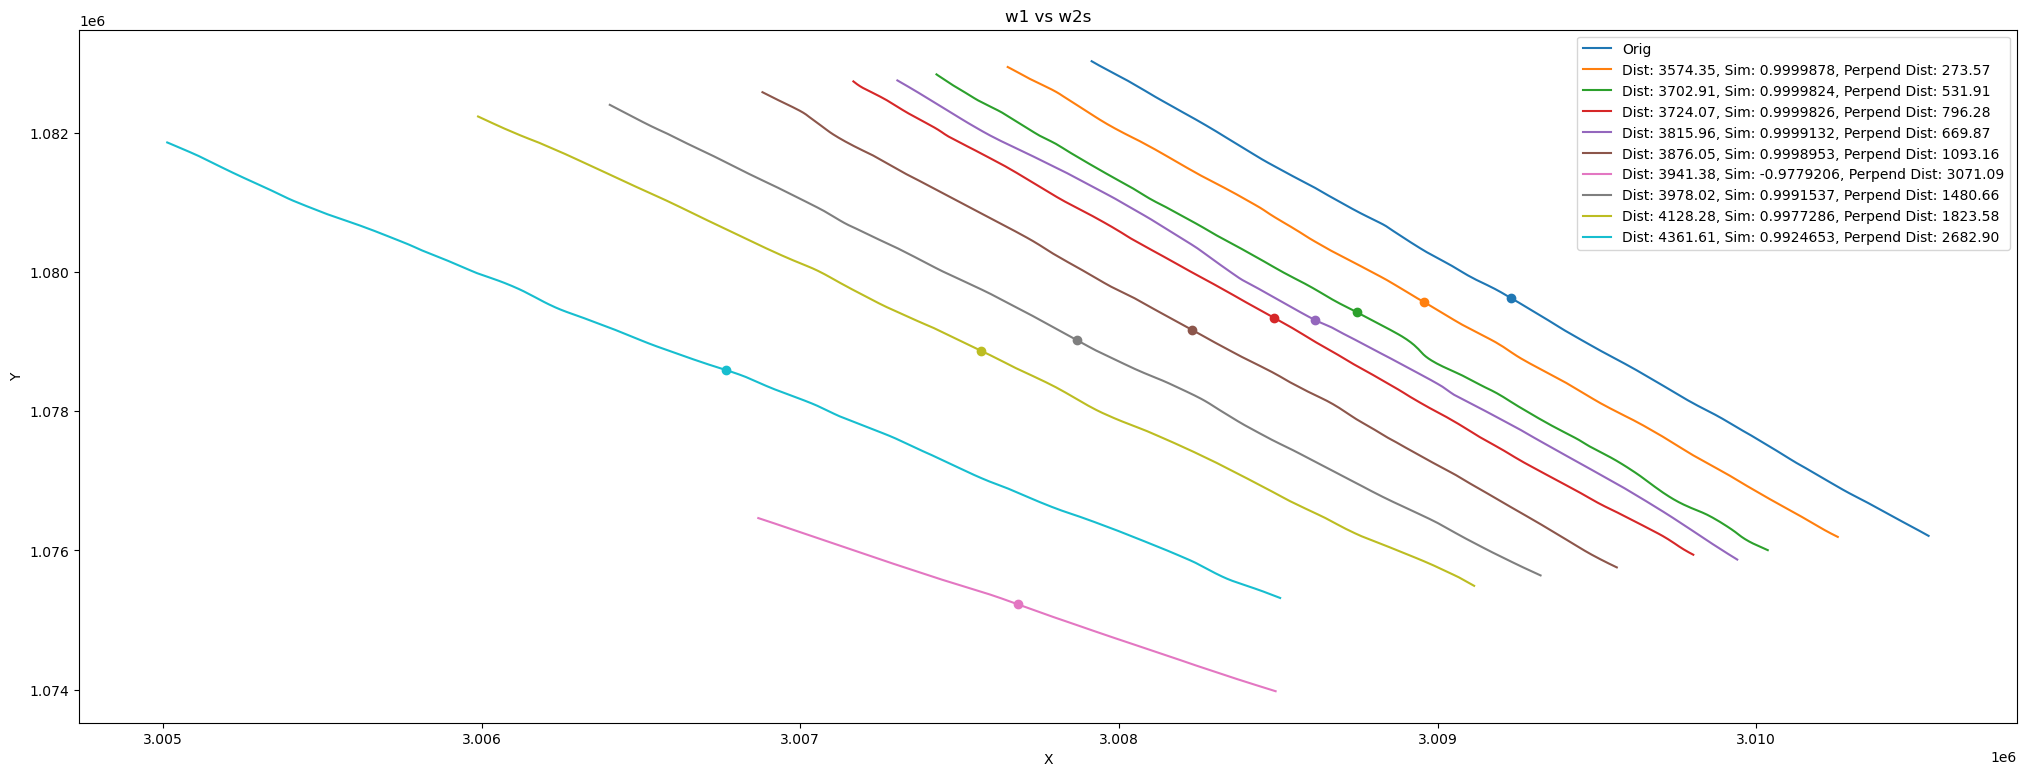

In [58]:
plt.figure(figsize=(25, 9))
plt.plot(e1['X'], e1['Y'], label='Orig')
plt.scatter(e1['X'].median(), e1['Y'].median())
for idx, dist in zip(local_candidate_indices, distances):
    w2 = well_names[idx]
    if w2 == w1:
        continue
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]
    
    result = calculate_well_similarity(e2, e1)

    plt.plot(e2['X'], e2['Y'], label=f"Dist: {dist:.2f}, Sim: {result['parallelism']:.7f}, Perpend Dist: {result['distance_ft']:.2f}")
    plt.scatter(e2['X'].median(), e2['Y'].median())

plt.xlabel('X')
plt.ylabel('Y')
plt.title('w1 vs w2s')
plt.legend()

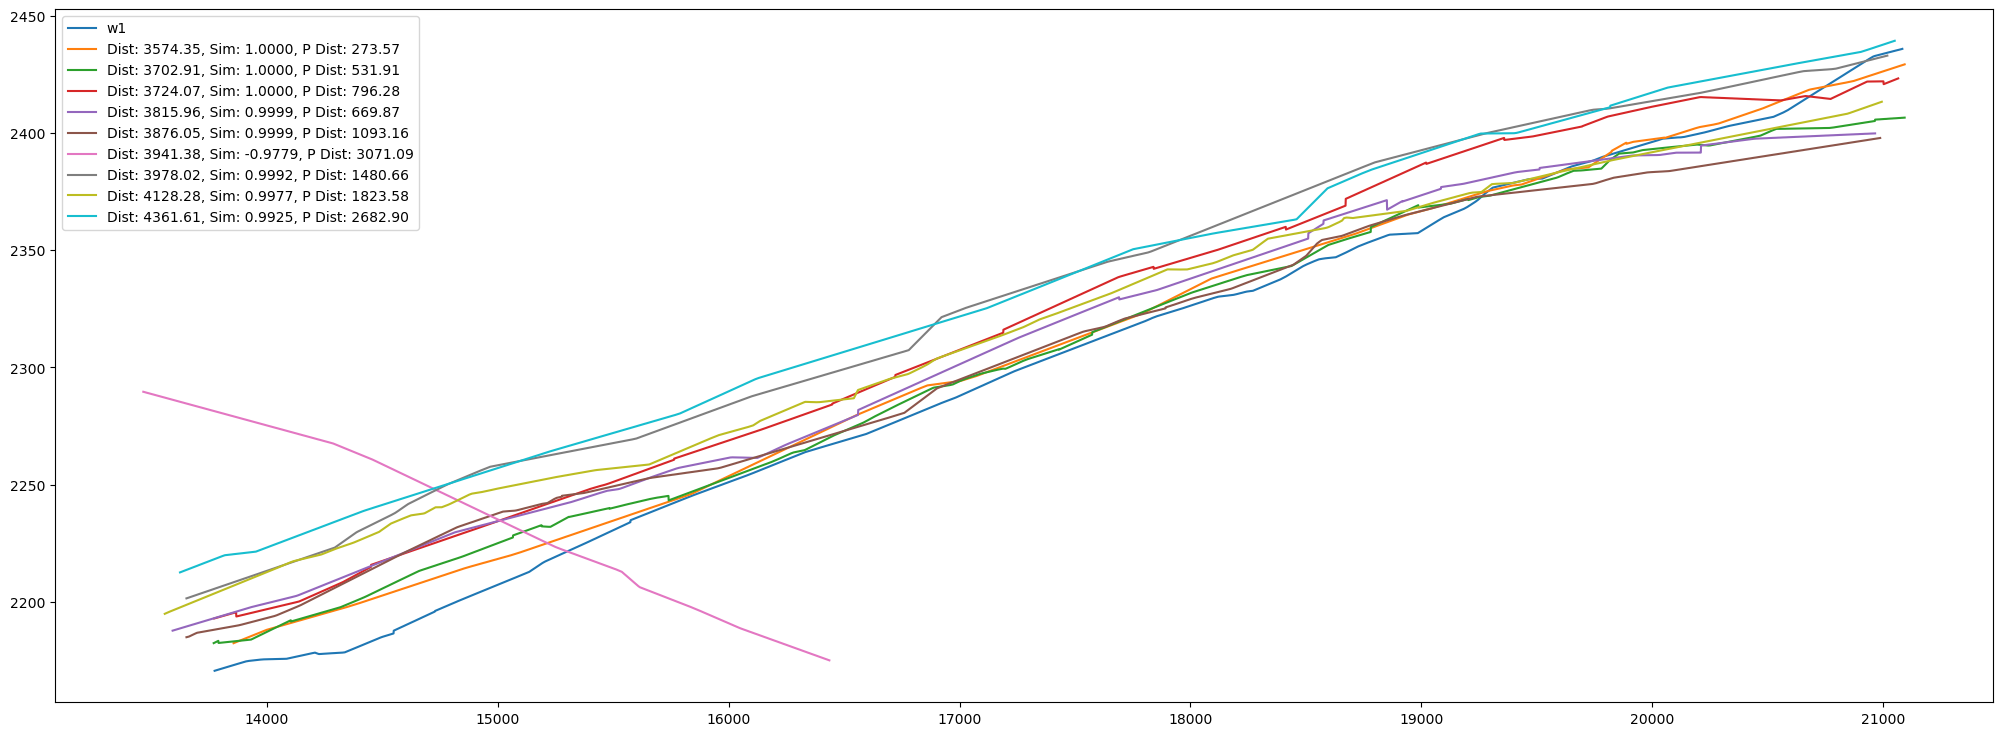

In [59]:
plt.figure(figsize=(25, 9))
y1 = e1['TVT'] + e1['Z']
plt.plot(e1['MD'], y1, label='w1')

pos_results = list()
neg_results = list()
for idx, dist in zip(local_candidate_indices[:], distances[:]):
    w2 = well_names[idx]
    if w2 == w1:
        continue
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]

    result = calculate_well_similarity(e2, e1)
    result['well'] = w2
    y2 = e2['TVT'] + e2['Z']
    plt.plot(e2['MD'], y2, label=f"Dist: {dist:.2f}, Sim: {result['parallelism']:.4f}, P Dist: {result['distance_ft']:.2f}")

    if result['parallelism'] > 0:
        pos_results.append(result)
    else:
        neg_results.append(result)

plt.legend()

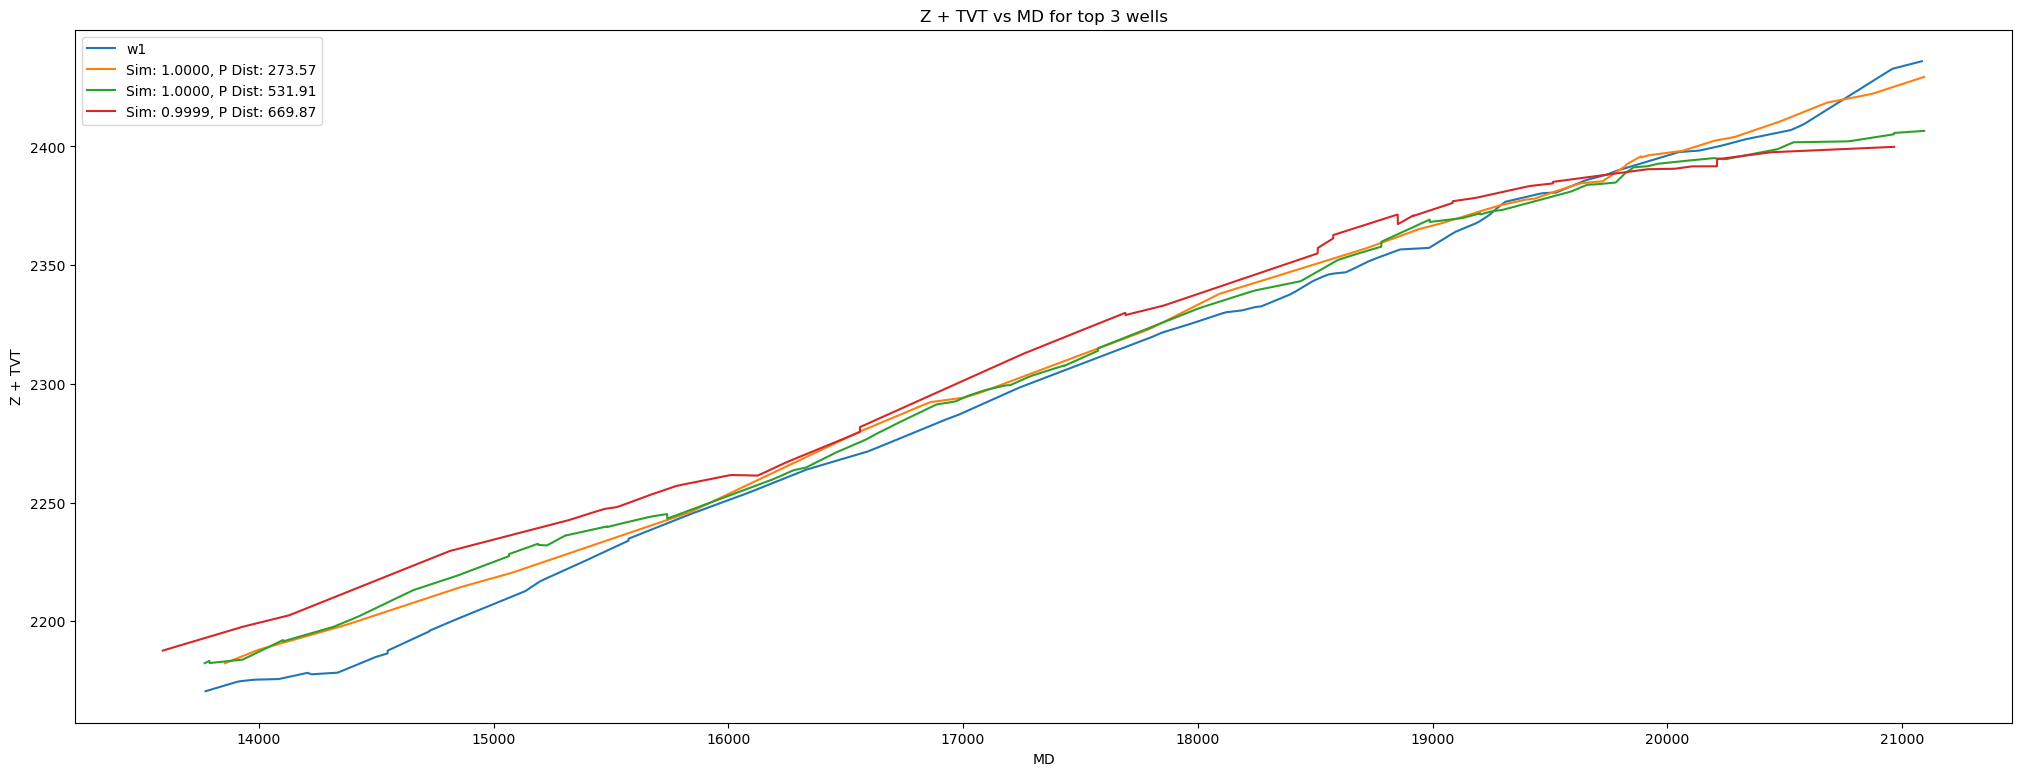

In [60]:
k = 3
top_results = (sorted(pos_results, key=lambda x:x['distance_ft']) + sorted(neg_results, key=lambda x:x['distance_ft']))[:k]

plt.figure(figsize=(25, 9))
y1 = e1['TVT'] + e1['Z']
plt.plot(e1['MD'], y1, label='w1')
for result in top_results:
    w2 = result['well']
    if w2 == w1:
        continue
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]

    result = calculate_well_similarity(e2, e1)
    result['well'] = w2
    y2 = e2['TVT'] + e2['Z']
    plt.plot(e2['MD'], y2, label=f"Sim: {result['parallelism']:.4f}, P Dist: {result['distance_ft']:.2f}")

plt.title(f'Z + TVT vs MD for top {k} wells')
plt.xlabel('MD')
plt.ylabel('Z + TVT')
plt.legend()

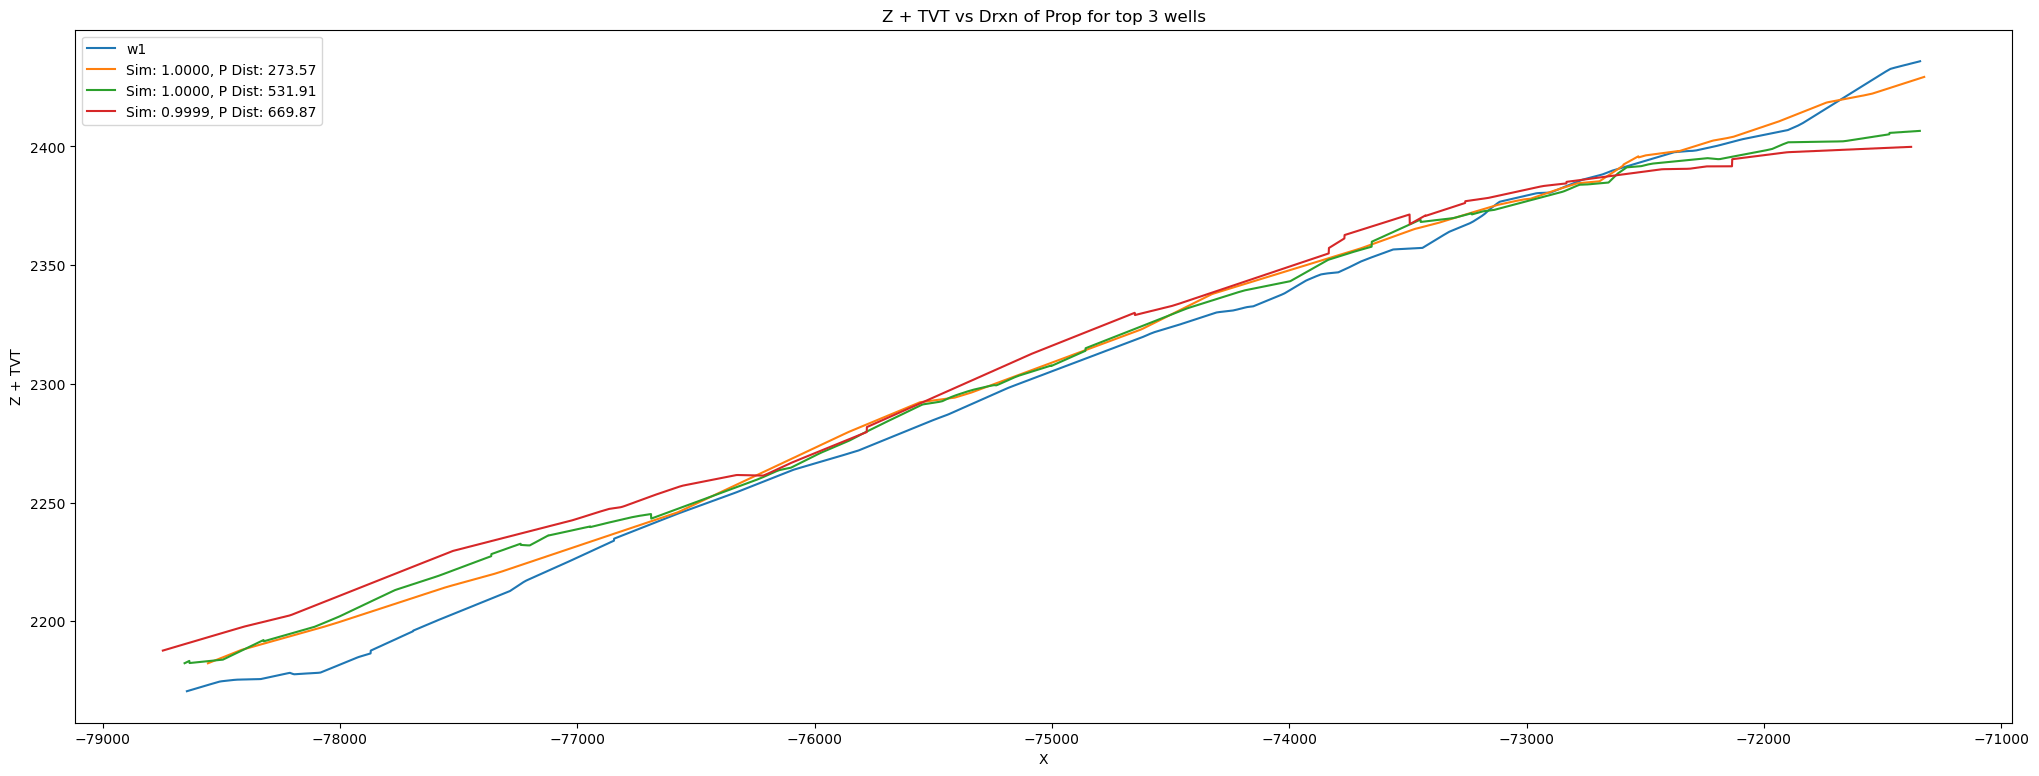

In [61]:
plt.figure(figsize=(25, 9))

theta = np.arctan2(e1["Y"].iloc[-1] - e1["Y"].iloc[0], e1["X"].iloc[-1] - e1["X"].iloc[0]) 
cos_t = np.cos(theta)
sin_t = np.sin(theta)
X1 = (e1["X"] * cos_t + e1["Y"] * sin_t)

plt.plot(X1 , e1['TVT'] + e1['Z'], label='w1')
for result in top_results:
    w2 = result['well']
    if w2 == w1:
        continue
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]

    result = calculate_well_similarity(e2, e1)
    X2 = (e2["X"] * cos_t + e2["Y"] * sin_t)
    if result['parallelism'] > 0:
        plt.plot(X2 ,e2['TVT'] + e2['Z'], label=f"Sim: {result['parallelism']:.4f}, P Dist: {result['distance_ft']:.2f}")

plt.title(f'Z + TVT vs Drxn of Prop for top {k} wells')
plt.xlabel('X')
plt.ylabel('Z + TVT')
plt.legend()

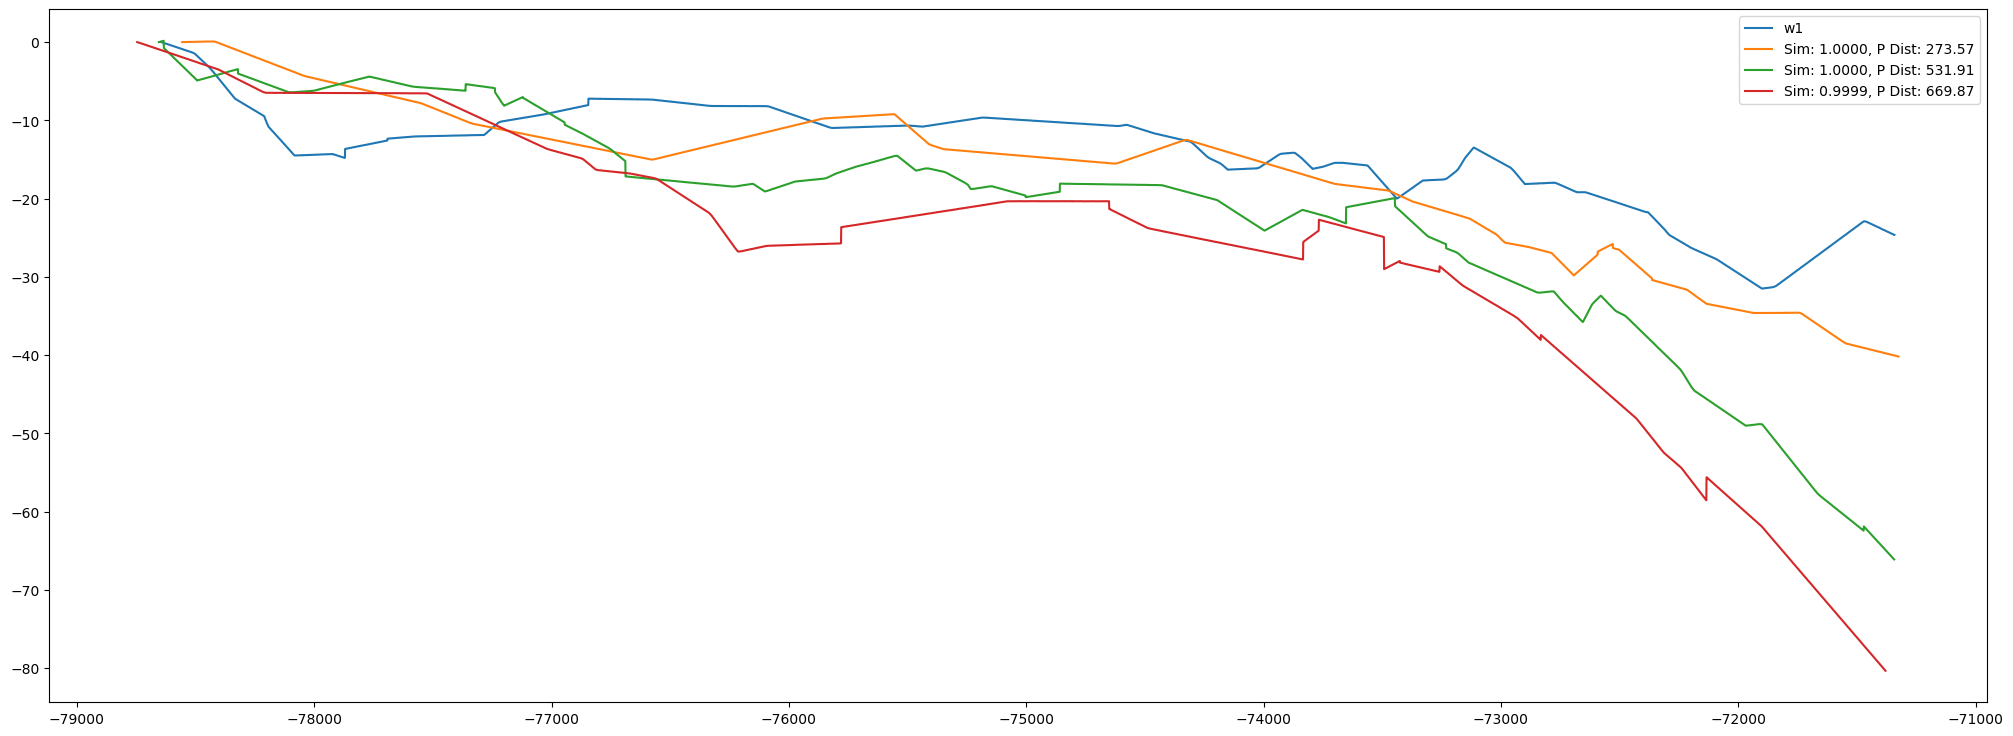

In [62]:
plt.figure(figsize=(25, 9))

theta = np.arctan2(e1["Y"].iloc[-1] - e1["Y"].iloc[0], e1["X"].iloc[-1] - e1["X"].iloc[0]) 
cos_t = np.cos(theta)
sin_t = np.sin(theta)
X1 = (e1["X"] * cos_t + e1["Y"] * sin_t)

m_, c_ = np.polyfit(X1, e1['Z'], deg=1)

y1 = e1['TVT'] + e1['Z'] - m_ * X1 
plt.plot(X1 , y1 - y1.iloc[0], label='w1')
for result in top_results:
    w2 = result['well']
    if w2 == w1:
        continue
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]

    result = calculate_well_similarity(e2, e1)
    X2 = (e2["X"] * cos_t + e2["Y"] * sin_t)
    y2 = e2['TVT'] + e2['Z'] - m_ * X2
    plt.plot(X2 ,y2 - y2.iloc[0], label=f"Sim: {result['parallelism']:.4f}, P Dist: {result['distance_ft']:.2f}")
    
plt.legend()

In [63]:
def project_neighbor_tvt(w1_df, w2_df, use_md=True):
    """
    Maps the known TVT (gt) from neighbor W2 onto target W1 
    by finding the closest points in the horizontal (X, Y) plane.
    """
    # Extract tracks
    if use_md:
        w2_coords = w2_df[['MD']].values
        w1_coords = w1_df[['MD']].values
    else:
        w2_coords = w2_df[['X', 'Y', 'Z']].values
        w1_coords = w1_df[['X', 'Y', 'Z']].values
    
    # Build spatial index for the neighbor well
    tree = KDTree(w2_coords)
    
    # Query the index: Find the closest row in W2 for every row in W1
    distances, closest_w2_indices = tree.query(w1_coords)
    
    # Copy the known target values ('TVT') from W2 to W1
    # Create a copy to prevent modifying the slice in place
    w1_mapped = w1_df.copy()
    w1_mapped['n_ztvt'] = (w2_df['TVT'] + w2_df['Z']).iloc[closest_w2_indices].values
    w1_mapped['dist_n'] = distances
    
    return w1_mapped

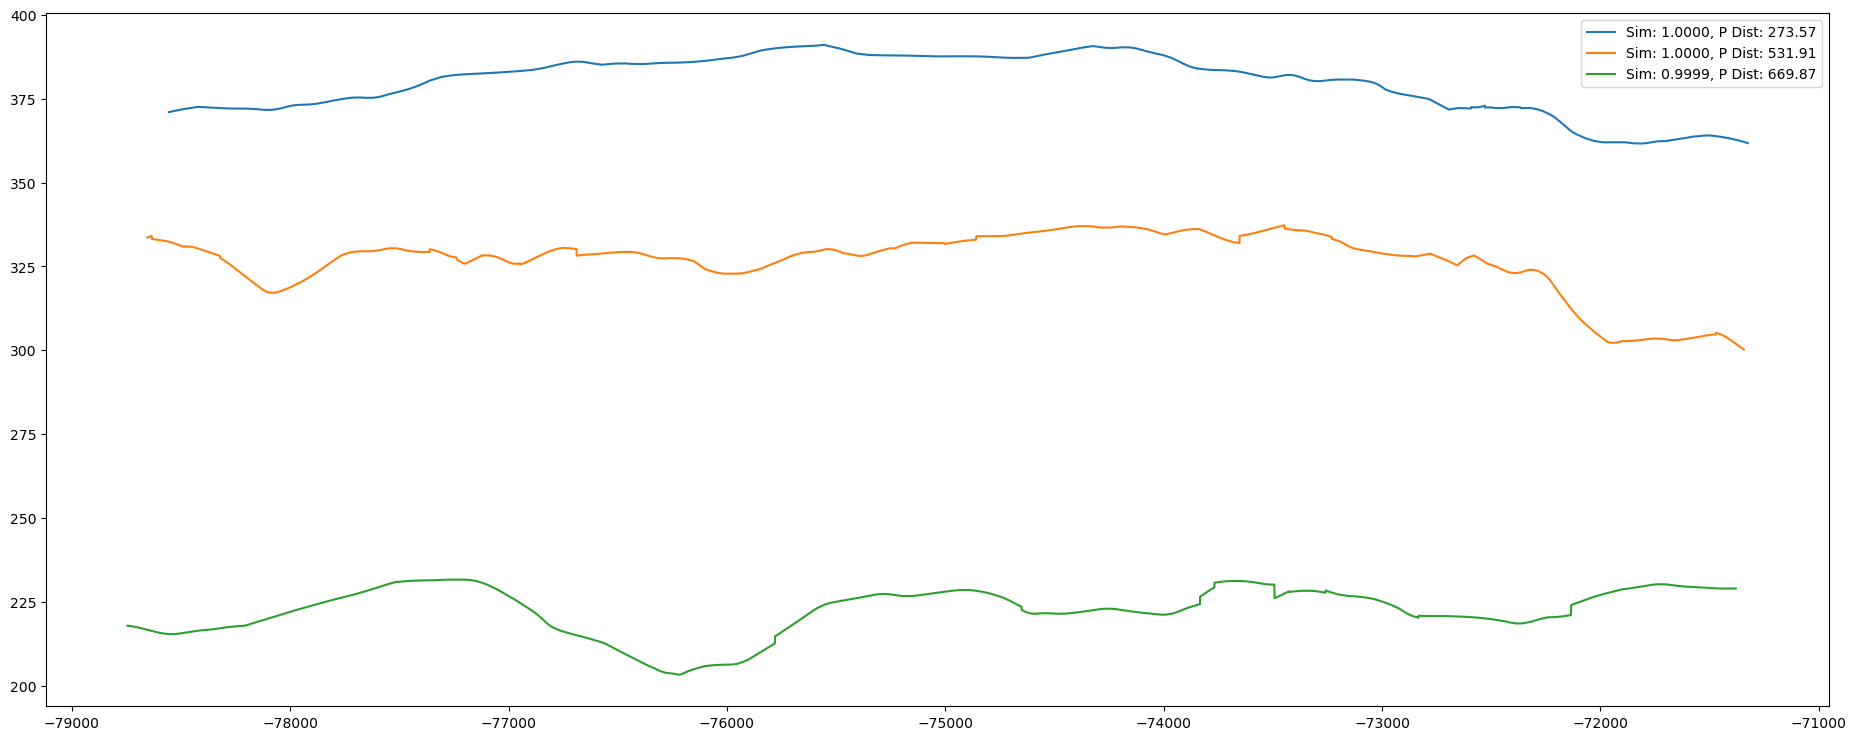

In [64]:
plt.figure(figsize=(23, 9))

for result in top_results:
    w2 = result['well']
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]

    result = calculate_well_similarity(e2, e1)
    X2 = (e2["X"] * cos_t + e2["Y"] * sin_t)
    y2 = e2['TVT'] + e2['Z'] - m_ * X2
    plt.plot(X2 ,e2['ANCC'] - e2['Z'], label=f"Sim: {result['parallelism']:.4f}, P Dist: {result['distance_ft']:.2f}")
    # plt.plot(X2 ,e2['TVT'], label=f"Sim: {result['parallelism']:.4f}, P Dist: {result['distance_ft']:.2f}")
    
plt.legend()

5.905634274054647
12.668474145364497
18.47231015024065


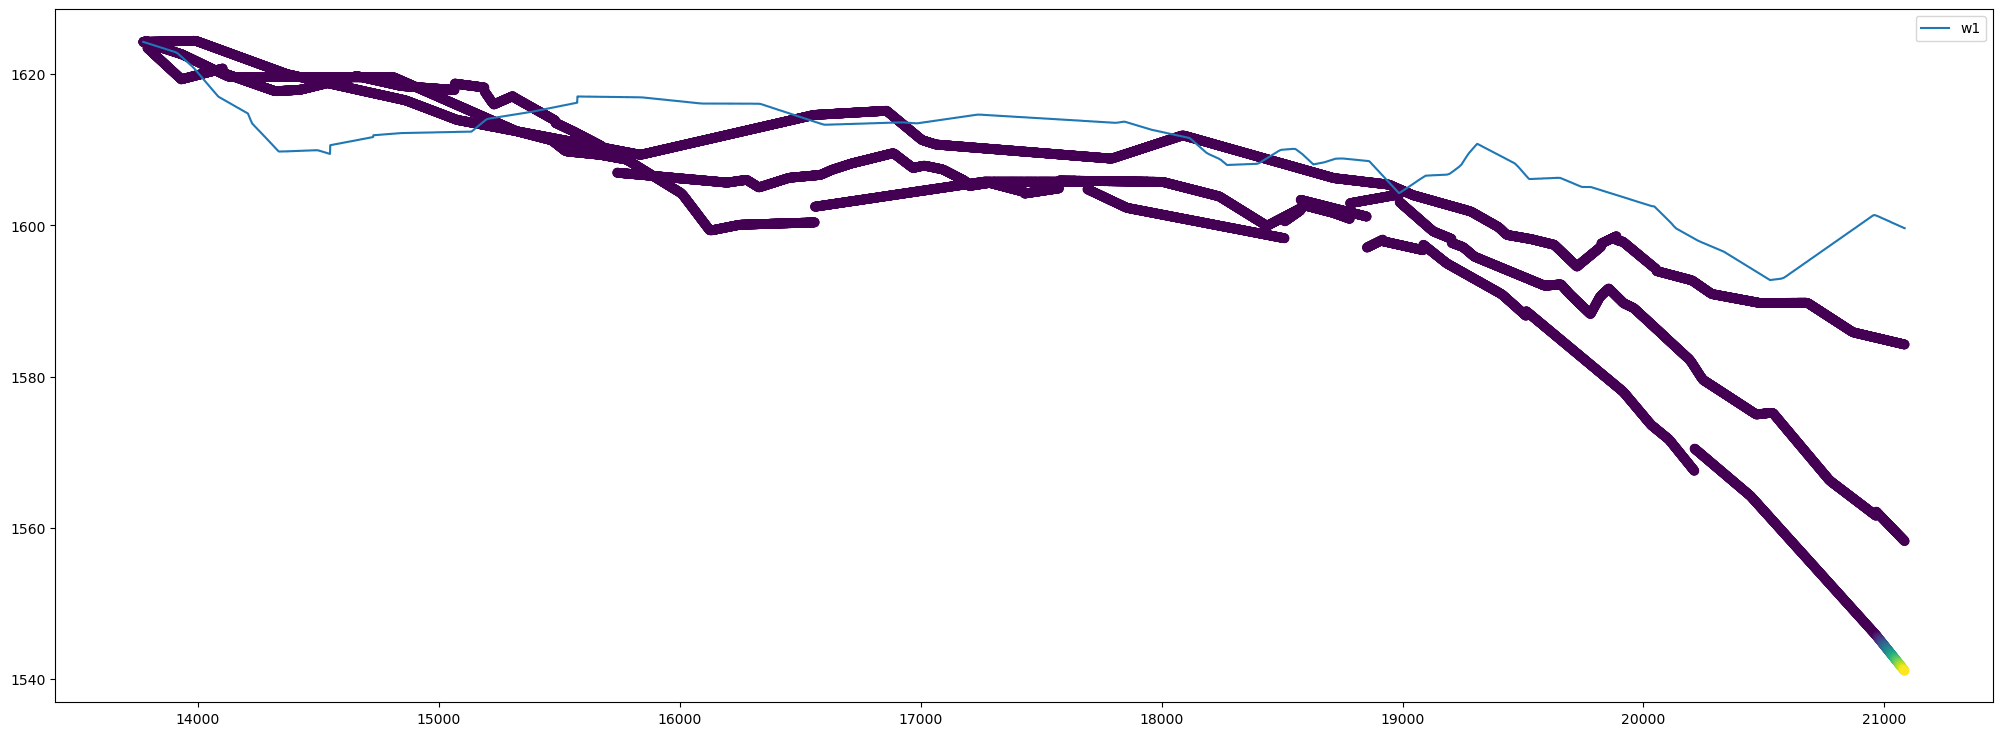

In [65]:
plt.figure(figsize=(25, 9))

def rmse(y1, y2):
    return np.sqrt(np.mean(np.square(y1.values - y2.values)))

y1 = e1['TVT'] + e1['Z'] - m1 * e1['MD']
plt.plot(e1['MD'], y1, label='w1')
for result in top_results:
    w2 = result['well']
    if w2 == w1:
        continue
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]
    m2, c2 = np.polyfit(e2['MD'], e2['Z'], deg=1)
    e1_mapped = project_neighbor_tvt(e1, h2)
    # y2 = e1_mapped['n_ztvt']- (m1)**2 * e1['MD'] / m2
    y2 = e1_mapped['n_ztvt']- (m1) * e1['MD'] 
    y2 = y2 - y2.iloc[0] + y1.iloc[0]
    plt.scatter(e1['MD'], y2, c=e1_mapped['dist_n'])
    print(rmse(y1, y2))

plt.legend()

5.644475217295624
11.964069986310152
18.301221816239863


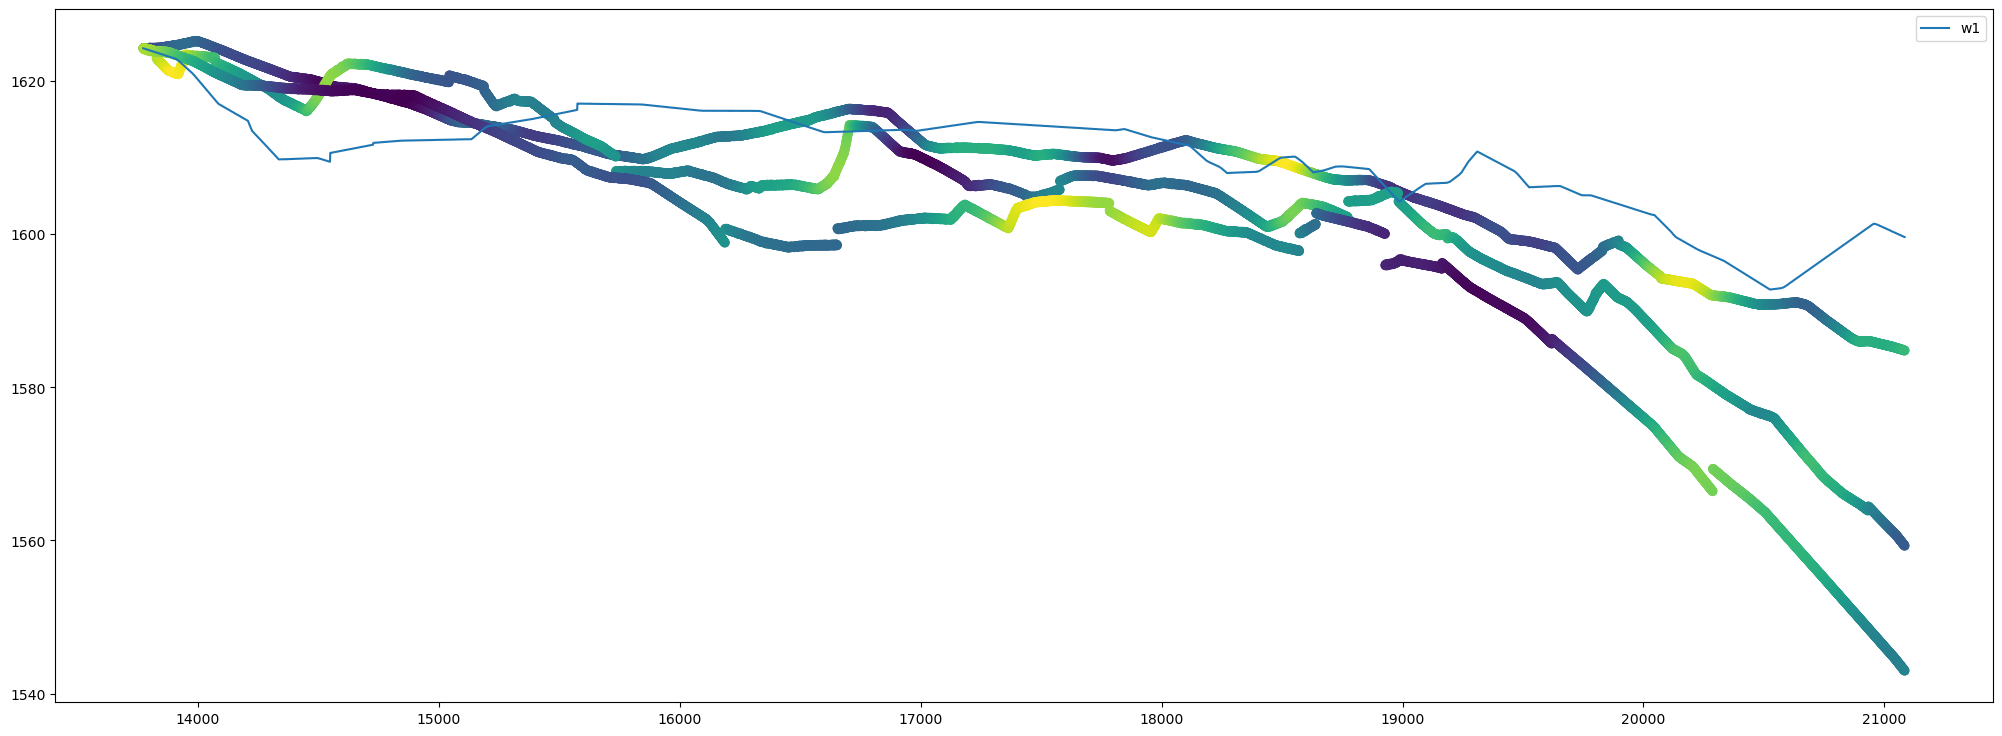

In [67]:
plt.figure(figsize=(25, 9))

y1 = e1['TVT'] + e1['Z'] - m1 * e1['MD']
plt.plot(e1['MD'], y1, label='w1')
for result in top_results:
    w2 = result['well']
    if w2 == w1:
        continue
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]
    e1_mapped = project_neighbor_tvt(e1, h2, use_md=False)
    y2 = e1_mapped['n_ztvt']- m1 * e1['MD']
    y2 = y2 - y2.iloc[0] + y1.iloc[0]
    plt.scatter(e1['MD'], y2, c=e1_mapped['dist_n'])
    print(rmse(y1, y2))

plt.legend()

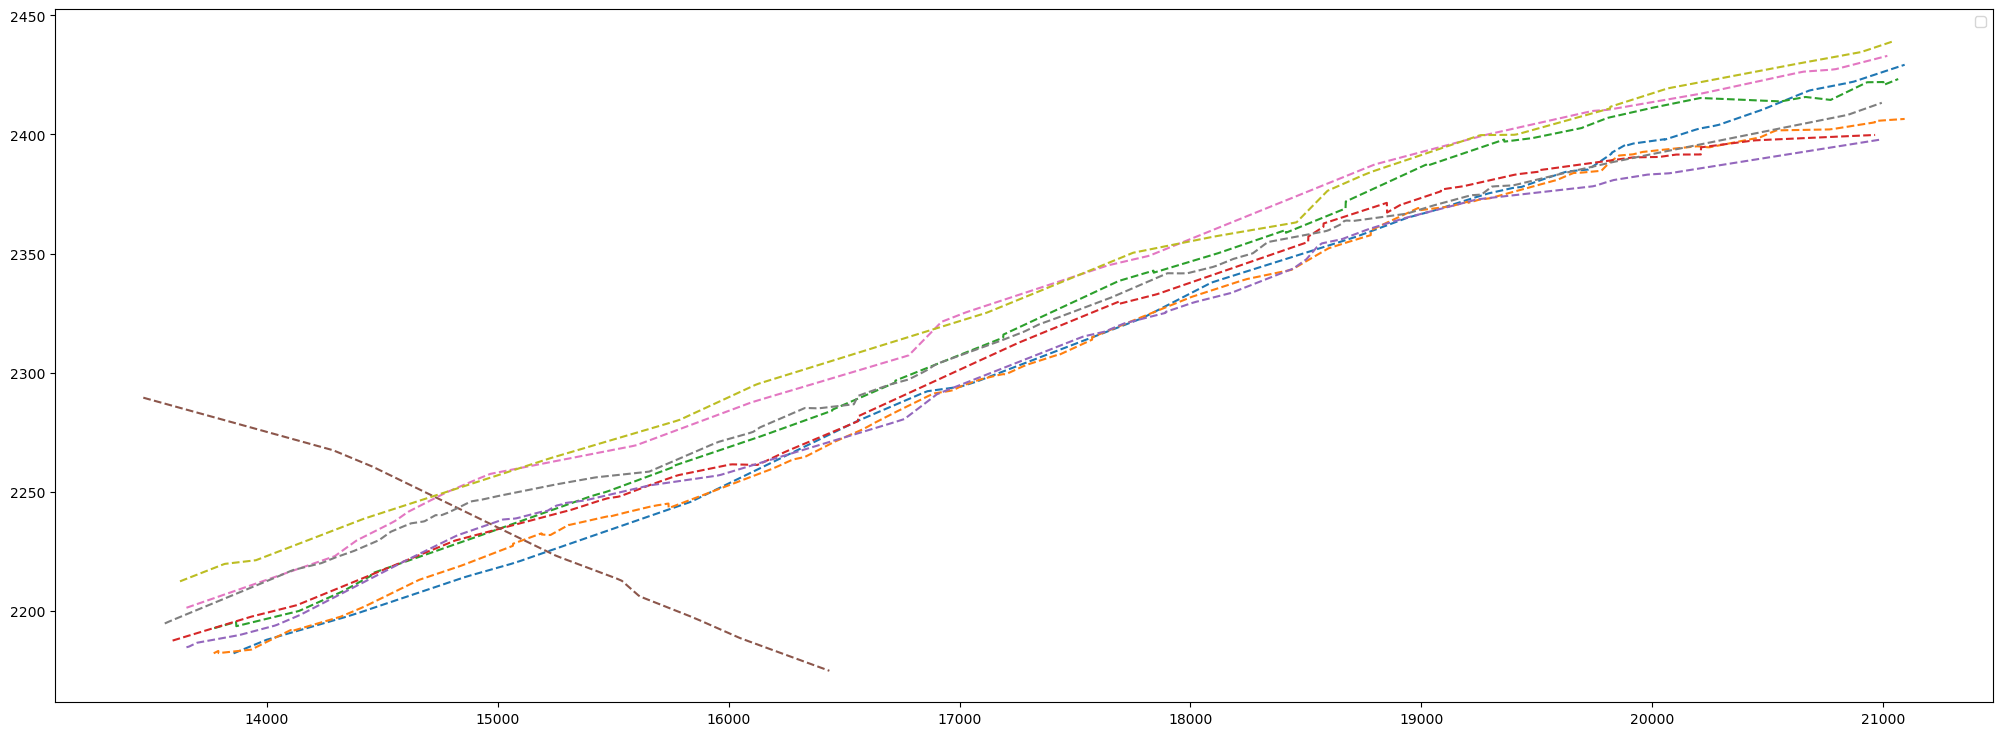

In [68]:
plt.figure(figsize=(25, 9))

y1 = e1['TVT'] + e1['Z'] - m1 * e1['MD']
# plt.plot(e1['MD'], y1, label='w1')
# for result in top_results:
for idx, dist in zip(local_candidate_indices, distances):
    w2 = well_names[idx]
    if w2 == w1:
        continue
    h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
    e2 = h2[h2['TVT_input'].isna()]
    k2 = h2[~h2['TVT_input'].isna()]
    e1_mapped = project_neighbor_tvt(e1, h2, use_md=False)
    y2 = e1_mapped['n_ztvt']- m1 * e1['MD']
    y2 = y2 - y2.iloc[0] + y1.iloc[0]
    # plt.plot(k2['MD'], k2['TVT'] + k2['Z'])
    plt.plot(e2['MD'], e2['TVT'] + e2['Z'], linestyle='dashed')

plt.legend()

In [69]:
from tqdm.notebook import tqdm

In [79]:
scores = list()

for w1 in tqdm(np.random.choice(well_names, size=100)):
    h1 = pd.read_csv(f'../data/train/{w1}__horizontal_well.csv')
    e1 = h1[h1['TVT_input'].isna()]
    x1, y1 = e1['X'].iloc[0], e1['Y'].iloc[0]
    m1, c1 = np.polyfit(e1['MD'], e1['Z'], deg=1)
    
    # Get K closes wells
    K = 10 
    distances, local_candidate_indices = start_tree.query([x1, y1], k=K)

    pos_results = list()
    neg_results = list()
    for idx, dist in zip(local_candidate_indices[:], distances[:]):
        w2 = well_names[idx]
        if w2 == w1:
            continue
        h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
        e2 = h2[h2['TVT_input'].isna()]
    
        result = calculate_well_similarity(e2, e1)
        result['well'] = w2
        y2 = e2['TVT'] + e2['Z']
    
        if result['parallelism'] > 0:
            pos_results.append(result)
        else:
            neg_results.append(result)

    k = 3
    top_results = (sorted(pos_results, key=lambda x:x['distance_ft']) + sorted(neg_results, key=lambda x:x['distance_ft']))[:k]

    y1 = e1['TVT'] + e1['Z'] - m1 * e1['MD'] - c1

    rmses = list() 
    for result in top_results[:]:
        w2 = result['well']
        if w2 == w1:
            continue
        h2 = pd.read_csv(f'../data/train/{w2}__horizontal_well.csv')
        e2 = h2[h2['TVT_input'].isna()]
        e1_mapped = project_neighbor_tvt(e1, h2)
        y2 = e1_mapped['n_ztvt']- m1 * e1['MD']
        y2 = y2 - y2.iloc[0] + y1.iloc[0]
        rmses.append((rmse(y1, y2), result['distance_ft'], result['parallelism'], len(e2)))

    scores.append(min(rmses, key=lambda x: x[0]))
    

  0%|          | 0/100 [00:00<?, ?it/s]

In [80]:
scores[:4]

[(np.float64(4.085629233667881),
  np.float64(403.4225774544771),
  np.float64(0.9999324474388557),
  3124),
 (np.float64(1.9708146486052507),
  np.float64(398.71163881710584),
  np.float64(0.9998722619301059),
  4722),
 (np.float64(6.948863470533885),
  np.float64(937.3816595458056),
  np.float64(0.9999516191455717),
  5885),
 (np.float64(57.079849196579666),
  np.float64(543.007224988612),
  np.float64(0.9989653611278508),
  3603)]

In [81]:
s = sorted(scores, key=lambda x:x[0], reverse=True)
s[:]

[(np.float64(162.01821213566217),
  np.float64(1019.2163304954588),
  np.float64(-0.9998969476295163),
  4510),
 (np.float64(128.8590088566389),
  np.float64(1654.165347546371),
  np.float64(-0.9985363668885885),
  4089),
 (np.float64(64.02671465885629),
  np.float64(9324.069922563576),
  np.float64(-0.09744044135352248),
  3628),
 (np.float64(60.16463625398719),
  np.float64(1985.515364321116),
  np.float64(0.9999746282508244),
  4772),
 (np.float64(57.079849196579666),
  np.float64(543.007224988612),
  np.float64(0.9989653611278508),
  3603),
 (np.float64(50.23405635829758),
  np.float64(390.7941858343671),
  np.float64(0.9999704136168924),
  6447),
 (np.float64(39.74245957650279),
  np.float64(2185.392787826199),
  np.float64(0.8659210456588646),
  3888),
 (np.float64(31.228686879921497),
  np.float64(9929.27412060749),
  np.float64(0.9997036512009801),
  3221),
 (np.float64(22.897037599013974),
  np.float64(3551.2391195029095),
  np.float64(0.9994170895998565),
  4683),
 (np.float6

In [82]:
s = np.array(s)
s.shape

(100, 4)

In [87]:
# RMSE
np.sqrt(np.sum((s[:, 0]**2) * s[:, 3])/ np.sum(s[:, 3]))

np.float64(24.299287660332478)

<Axes: >

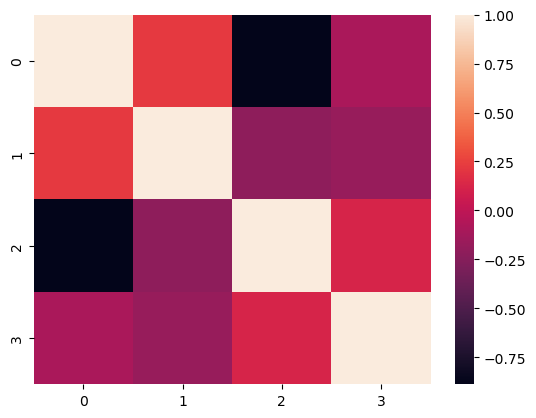

In [84]:
import seaborn as sns
# RMSE, DISTANCE, Parallelism, Length
sns.heatmap(pd.DataFrame(s).corr())

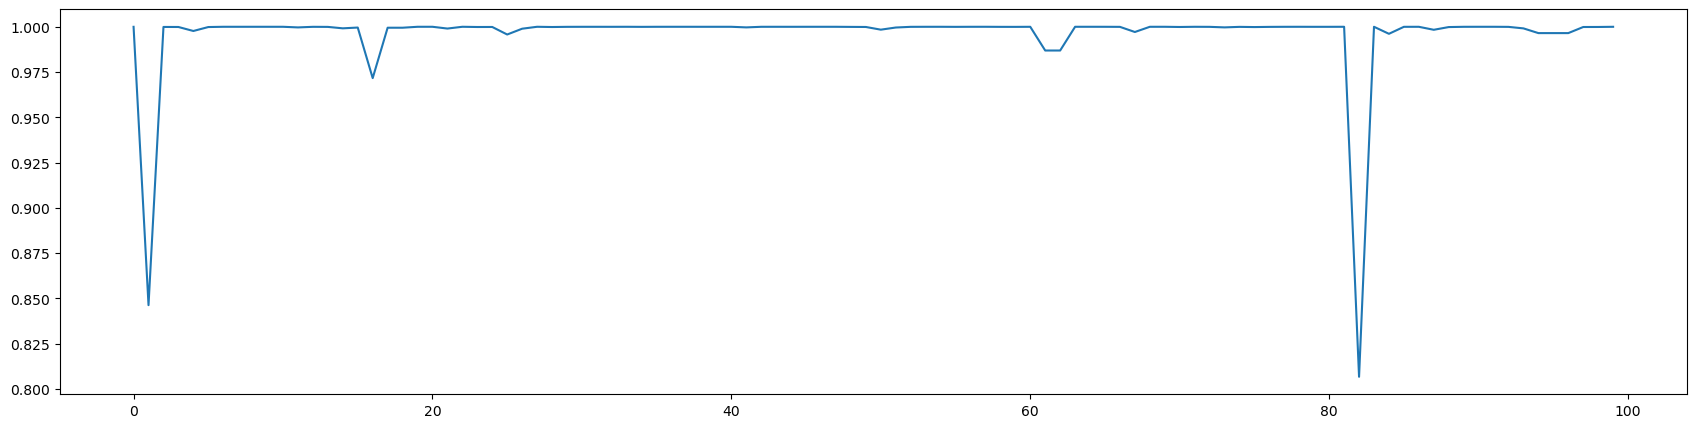

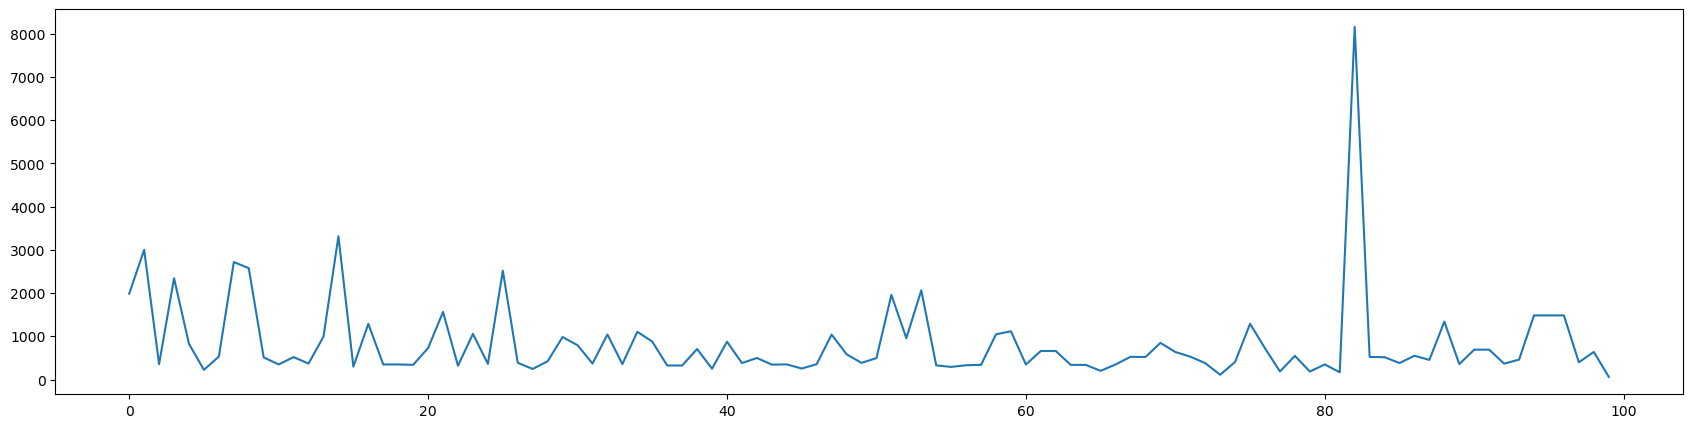

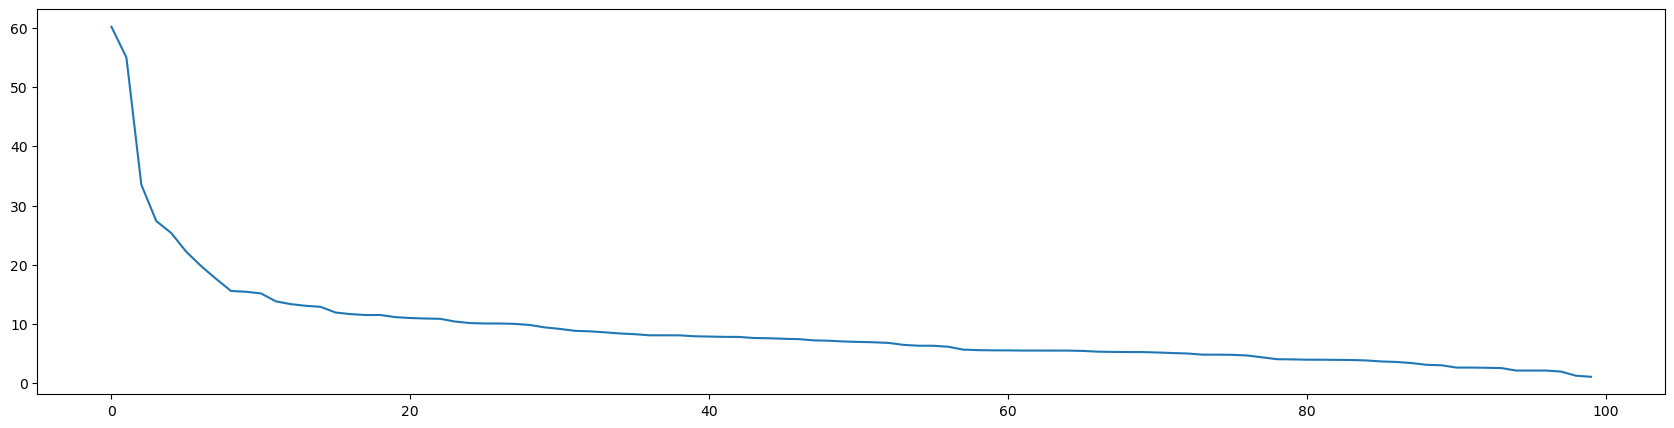

In [78]:
plt.figure(figsize=(21, 5))
plt.plot(s[:, 2])
plt.figure(figsize=(21, 5))
plt.plot(s[:, 1])
plt.figure(figsize=(21, 5))
plt.plot(s[:, 0])

In [51]:
# --- STEP 1: GLOBAL CACHE + EXTRACT START POINTS ---
well_cache = {}
start_points = []
valid_wells = []

for w in tqdm(well_names[:], desc='Loading & Indexing Well Starts'):
    h = pd.read_csv(f'../data/train/{w}__horizontal_well.csv')
    e = h[h['TVT_input'].isna()].copy()
    
    well_cache[w] = (h, e)
    # Extract the XYZ coordinates of the very first row
    start_coords = e[['X', 'Y']].iloc[0].values
    start_points.append(start_coords)
    valid_wells.append(w)

Loading & Indexing Well Starts:   0%|          | 0/773 [00:00<?, ?it/s]

In [52]:
# Max least distance between 2 wells

closest_distances = list()
sp = start_points
for p1 in tqdm(start_points[:]):
    dist = float('inf')
    for p2 in start_points:
        if (p1==p2).all():
            continue
        cand_dist = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)
        if dist > cand_dist:
            dist = cand_dist
    closest_distances.append(dist) 

m = np.argmax(closest_distances)
sorted(closest_distances, reverse=True)[:5], valid_wells[m], start_points[m]

  0%|          | 0/773 [00:00<?, ?it/s]

([np.float64(13122.275924983493),
  np.float64(7057.918379040731),
  np.float64(6419.616413034326),
  np.float64(6376.147547641991),
  np.float64(5392.9600294086)],
 '059c8f24',
 array([2913888.92, 1065892.02]))

In [53]:
# Build a spatial search tree exclusively for the well start locations
start_points = np.array(start_points)
start_tree = KDTree(start_points)

In [54]:
all_dfs = []

# --- STEP 2: RADIUS-FILTERED PROCESSING ---
for idx1, w1 in enumerate(tqdm(valid_wells[:], desc='Processing Local Alignments')):
    h1, e1 = well_cache[w1]
    
    # Fast Spatial Filter: Instantly get indices of wells starting within a 2000-unit radius
    # This eliminates the O(N^2) inner comparison overhead completely
    distances, local_candidate_indices = start_tree.query(start_points[idx1], k=3)
        
    results = []
    for idx2 in local_candidate_indices:
        w2 = valid_wells[idx2]
        if w2 == w1:
            continue
        h2, e2 = well_cache[w2]
        
        # Expensive track similarity is ONLY called for confirmed close neighbors
        result = calculate_well_similarity(e2, e1)
        result['well_name'] = w2
        results.append(result)
        
    if not results:
        print(f"!!! RESULTS NOT FOUND FOR {w1}")
        continue # Skip if the well is isolated with no neighbors within 2000 units
        
    # Sort and pick top 3 closest parallel neighbors from the local candidates
    top_3_neighbors = sorted(results, key=lambda x: x['distance_ft'])[:3]
    top_3_neighbors = sorted(top_3_neighbors, key=lambda x: x['parallelism'])

    # Pre-calculate target trajectories and trends
    m1, c1 = np.polyfit(e1['MD'], e1['Z'], deg=1)
    detrend_line = m1 * e1['MD'] + c1
    y1 = e1['TVT'] + e1['Z'] - e1['TVT'].iloc[0] - detrend_line

    for result in top_3_neighbors:
        w2 = result['well_name']
        h2, e2 = well_cache[w2]
        
        e1_mapped = project_neighbor_tvt(e1, h2, e2['TVT'].iloc[0]) 
        
        y2 = e1_mapped['neighbor_tvt'] - detrend_line
        y2 = y2 - y2.iloc[0] + y1.iloc[0]
        
        temp_df = pd.DataFrame({
            'well': w1,
            'neighbor_well': w2,
            'z+tvt': y1,
            'proj_tvt': y2,
            'dist': e1_mapped['dist_to_neighbor']
        })
        all_dfs.append(temp_df)

# --- STEP 3: FINAL CONCATENATION ---
df_results = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
print(df_results.head())

Processing Local Alignments:   0%|          | 0/773 [00:00<?, ?it/s]

KeyError: 'neighbor_tvt'

In [ ]:
df_results.to_csv('../data/near_wells4.csv')
# df_results = pd.read_csv('../data/near_wells4.csv')

In [ ]:
plt.figure(figsize=(21, 5))

w1 = np.random.choice(df_results['well'].unique())
h1 = pd.read_csv(f'../data/train/{w1}__horizontal_well.csv')
e1 = h1[h1['TVT_input'].isna()].copy()
d1 = df_results[df_results['well'] == w1]

m1, c1 = np.polyfit(e1['MD'], e1['Z'], deg=1)
y1 = e1['TVT'] + e1['Z'] - e1['TVT'].iloc[0] - (m1 * e1['MD'] + c1)

plt.plot(e1['MD'], y1)
for w2 in d1['neighbor_well'].unique()[:]:
    d2 = d1[d1['neighbor_well'] == w2]
    y2 = d2['proj_tvt']
    plt.scatter(e1['MD'], y2, c=d2['dist'])
    print(f'Score (RMSE): {np.sqrt(np.mean((y1.values -y2.values)**2)):.2f}')    
    
plt.title('{w1}, {w2}')

In [ ]:
# 1. Assign a rank (1, 2, 3) to neighbors based on their order of appearance per well
pairs = df_results[['well', 'neighbor_well']].drop_duplicates().copy()
pairs['rank'] = pairs.groupby('well').cumcount() + 1
df_ranked = df_results.merge(pairs, on=['well', 'neighbor_well'])

# 2. Create a row-sequential index to align the points across different neighbors
df_ranked['point_idx'] = df_ranked.groupby(['well', 'neighbor_well']).cumcount()

# 3. Pivot the table from long format to wide format
df_wide = df_ranked.pivot(
    index=['well', 'point_idx', 'z+tvt'], 
    columns='rank', 
    values=['proj_tvt', 'dist']
)

# 4. Flatten the multi-index columns into the exact names you requested
df_wide.columns = [
    f"proj{rank}" if metric == 'proj_tvt' else f"dist{rank}" 
    for metric, rank in df_wide.columns
]

# 5. Clean up the tracking index
df_final = df_wide.reset_index().drop(columns=['point_idx'])

(df_final.head())

In [ ]:
df_final.to_csv('../data/near_wells5.csv')
# df_final = pd.read_csv('../data/near_wells3.csv')

In [ ]:
np.mean(np.abs((df_final['z+tvt'] - df_final['proj1'])))

## Trouble Shooting Graphs:

2995712.36 1113465.8


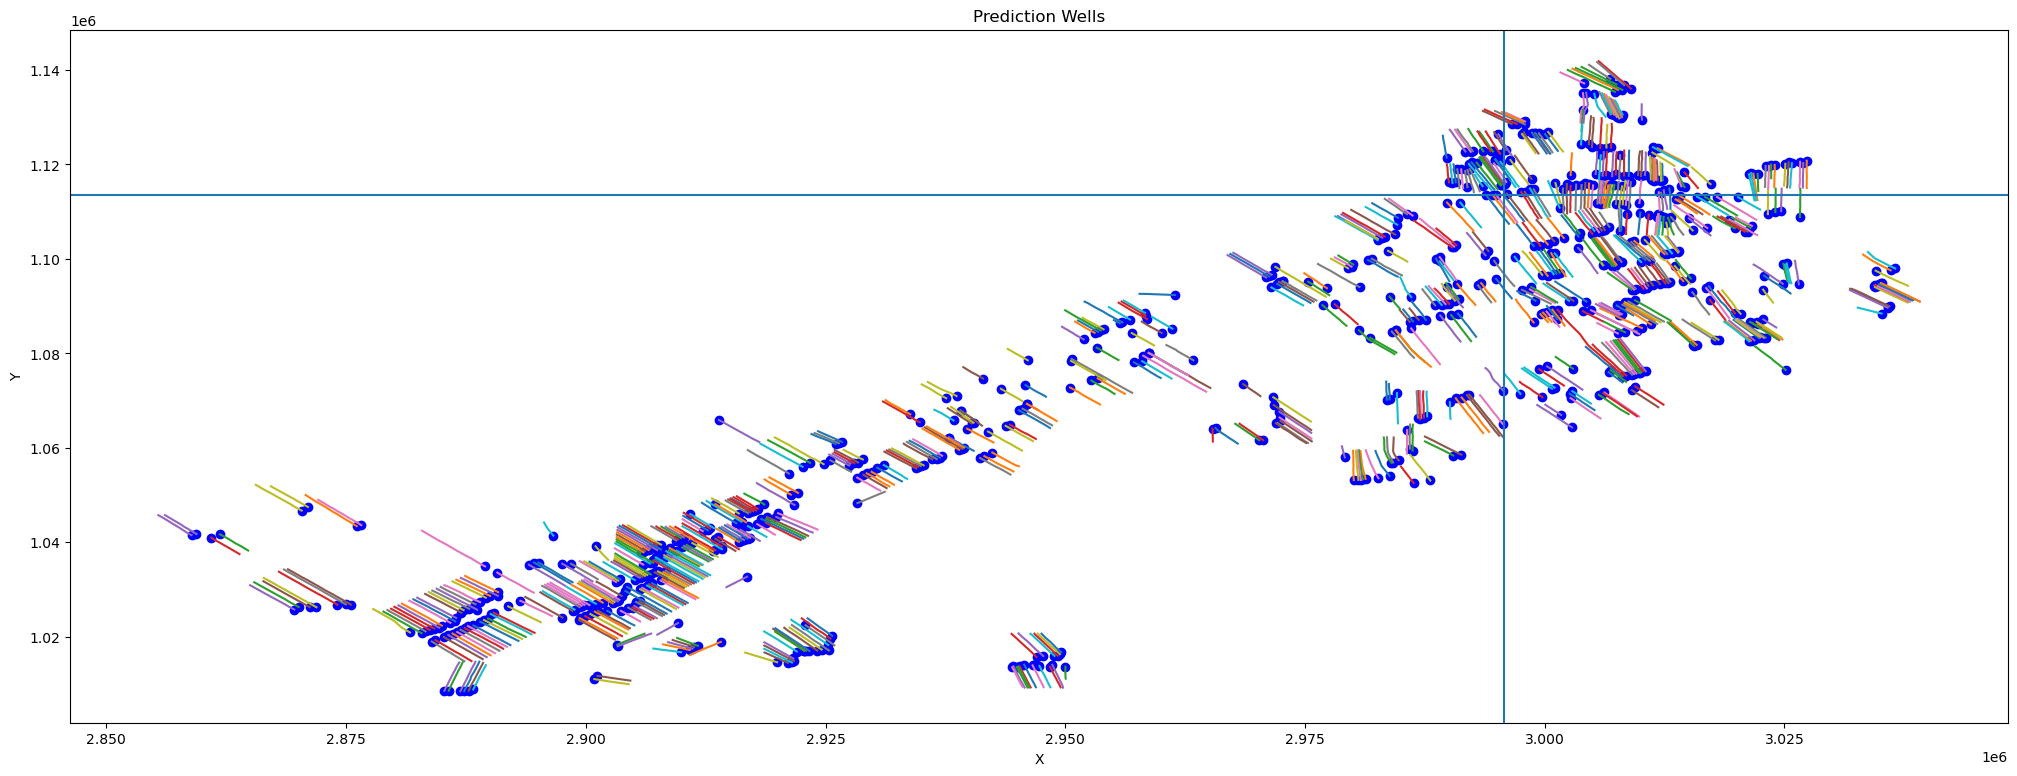

In [88]:
plt.figure(figsize=(25, 9))
for well in sorted(well_names[:]):
    hw = pd.read_csv(f'../data/train/{well}__horizontal_well.csv')
    evalz = hw[hw['TVT_input'].isna()]
    plt.plot(evalz['X'], evalz['Y'])
    m1, c1 = np.polyfit(evalz['MD'], evalz['Z'], deg=1)
    if (well == 'b977be4a'):
        print(evalz['X'].iloc[0], evalz['Y'].iloc[0])
        X = evalz['X'].iloc[0]
        Y = evalz['Y'].iloc[0]
    else:
        plt.scatter(evalz['X'].iloc[0], evalz['Y'].iloc[0], color='blue', marker='o')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Prediction Wells')

# plt.scatter(X, Y, color='red', marker='o', s=200)
plt.axvline(x=X)
plt.axhline(y=Y)
